# ⚖️ Bias-Variance Tradeoff & Regularization

Every metric in the previous topic measured *how wrong* a model is. This topic asks *why* it's wrong: too simple (high bias, underfitting) or too sensitive to its specific training sample (high variance, overfitting) — and derives the tool built specifically to trade one for the other: regularization.

📖 Full mathematical explanation (bias-variance decomposition, Ridge/Lasso derivations, regularization path theory): [README.md](README.md)


## 1. Setup & Datasets

A synthetic 1D nonlinear function (so bias/variance can be *seen* visually as fitted-curve shape) plus the Diabetes dataset (for regularization on real, moderately correlated features).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, learning_curve, validation_curve, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_function(x):
    return np.sin(1.6 * np.pi * x)

n_samples = 60
X_1d = np.sort(np.random.uniform(0, 1, n_samples))
y_1d = true_function(X_1d) + np.random.normal(0, 0.25, n_samples)
X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(
    X_1d.reshape(-1, 1), y_1d, test_size=0.3, random_state=42
)
print(f"1D dataset: {n_samples} points, train={len(X_1d_train)}, test={len(X_1d_test)}")


1D dataset: 60 points, train=42, test=18


In [3]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)
print(f"Diabetes dataset: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")
print(f"Feature correlations (max off-diagonal): {np.abs(np.corrcoef(Xd_train.T) - np.eye(Xd.shape[1])).max():.3f}")


Diabetes dataset: 10 features, train=(331, 10), test=(111, 10)
Feature correlations (max off-diagonal): 0.893


## 2. Seeing Underfitting and Overfitting Directly

Fitting polynomials of increasing degree to the same noisy 1D data. Degree 1 is too simple to capture the curve (high bias); degree 15 chases the noise itself (high variance).


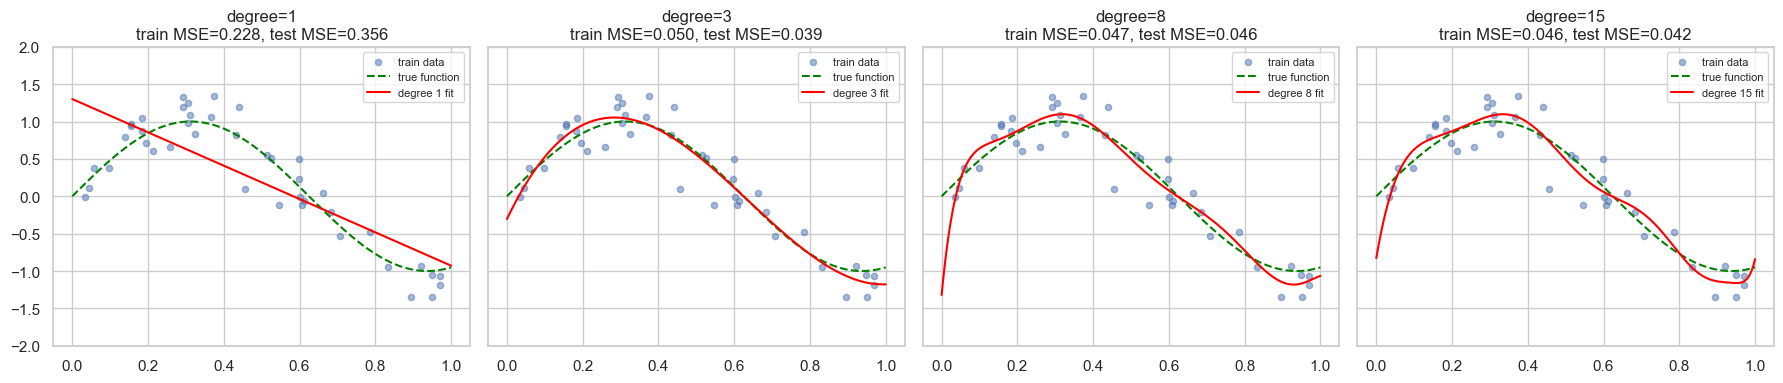

In [4]:
degrees_to_show = [1, 3, 8, 15]
x_plot = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, degree in zip(axes, degrees_to_show):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_1d_train, y_1d_train)
    y_plot = model.predict(x_plot)
    train_mse = mean_squared_error(y_1d_train, model.predict(X_1d_train))
    test_mse = mean_squared_error(y_1d_test, model.predict(X_1d_test))

    ax.scatter(X_1d_train, y_1d_train, alpha=0.5, s=20, label="train data")
    ax.plot(x_plot, true_function(x_plot), color="green", linestyle="--", label="true function")
    ax.plot(x_plot, y_plot, color="red", label=f"degree {degree} fit")
    ax.set_title(f"degree={degree}\ntrain MSE={train_mse:.3f}, test MSE={test_mse:.3f}")
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading the panel above:** degree 1 has high train *and* test error (can't represent a sine wave at all — high bias). Degree 15 has near-zero train error but visibly wild oscillation between data points, and typically the worst test error of the four (high variance). The best degree is somewhere in between, where the fitted curve tracks the true function without chasing individual noisy points.


## 3. The Bias-Variance Decomposition, Measured Empirically

For a fixed test point $x_0$, if we resample the training set many times and refit, the expected squared error decomposes as:

$$\mathbb{E}[(y_0 - \hat f(x_0))^2] = \underbrace{(\text{Bias}[\hat f(x_0)])^2}_{\text{systematic error}} + \underbrace{\text{Var}[\hat f(x_0)]}_{\text{sensitivity to training sample}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

This cell estimates Bias² and Variance directly by bootstrap-resampling the training set many times per polynomial degree.


In [5]:
def bias_variance_estimate(degree, n_bootstrap=100):
    predictions = np.zeros((n_bootstrap, len(x_plot)))
    rng = np.random.RandomState(0)
    for b in range(n_bootstrap):
        idx = rng.choice(len(X_1d_train), size=len(X_1d_train), replace=True)
        Xb, yb = X_1d_train[idx], y_1d_train[idx]
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(Xb, yb)
        predictions[b] = model.predict(x_plot).ravel()

    mean_pred = predictions.mean(axis=0)
    true_vals = true_function(x_plot).ravel()
    bias_sq = np.mean((mean_pred - true_vals) ** 2)
    variance = np.mean(predictions.var(axis=0))
    return bias_sq, variance

degrees_range = [1, 2, 3, 5, 8, 11, 15, 20]
bias_sq_list, variance_list = [], []
for d in degrees_range:
    b_sq, v = bias_variance_estimate(d)
    bias_sq_list.append(b_sq)
    variance_list.append(v)
    print(f"degree={d:>2}: Bias^2={b_sq:.4f}, Variance={v:.4f}, Bias^2+Variance={b_sq+v:.4f}")


degree= 1: Bias^2=0.1825, Variance=0.0138, Bias^2+Variance=0.1963
degree= 2: Bias^2=0.0590, Variance=0.0084, Bias^2+Variance=0.0675
degree= 3: Bias^2=0.0071, Variance=0.0037, Bias^2+Variance=0.0109


degree= 5: Bias^2=0.0062, Variance=0.0093, Bias^2+Variance=0.0155
degree= 8: Bias^2=0.0387, Variance=0.0900, Bias^2+Variance=0.1287
degree=11: Bias^2=0.0568, Variance=0.1571, Bias^2+Variance=0.2139


degree=15: Bias^2=0.2758, Variance=18.2550, Bias^2+Variance=18.5308
degree=20: Bias^2=4.5435, Variance=228.5279, Bias^2+Variance=233.0714


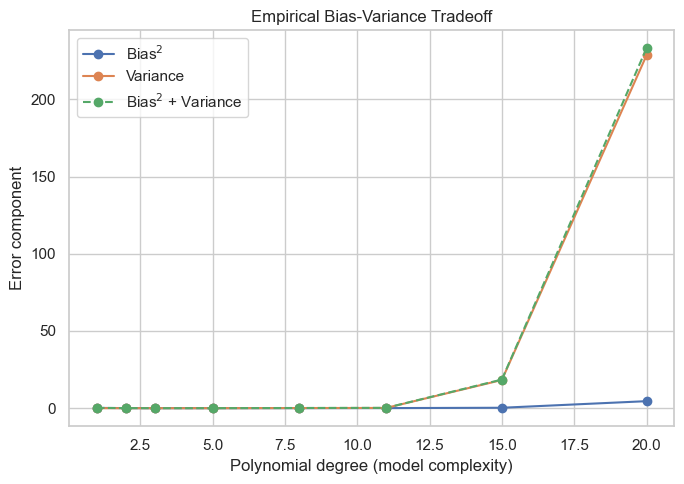

Degree minimizing Bias^2 + Variance: 3


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(degrees_range, bias_sq_list, marker="o", label="Bias$^2$")
ax.plot(degrees_range, variance_list, marker="o", label="Variance")
ax.plot(degrees_range, np.array(bias_sq_list) + np.array(variance_list), marker="o", linestyle="--", label="Bias$^2$ + Variance")
ax.set_xlabel("Polynomial degree (model complexity)")
ax.set_ylabel("Error component")
ax.set_title("Empirical Bias-Variance Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()

best_degree = degrees_range[int(np.argmin(np.array(bias_sq_list) + np.array(variance_list)))]
print(f"Degree minimizing Bias^2 + Variance: {best_degree}")


In [7]:
bias_variance_df = pd.DataFrame({
    "degree": degrees_range,
    "bias_sq": np.round(bias_sq_list, 4),
    "variance": np.round(variance_list, 4),
    "total": np.round(np.array(bias_sq_list) + np.array(variance_list), 4),
})
bias_variance_df


,degree,bias_sq,variance,total
0,1,0.1825,0.0138,0.1963
1,2,0.0590,0.0084,0.0675
2,3,0.0071,0.0037,0.0109
3,5,0.0062,0.0093,0.0155
4,8,0.0387,0.0900,0.1287
5,11,0.0568,0.1571,0.2139
6,15,0.2758,18.2550,18.5308
7,20,4.5435,228.5279,233.0714


## 4. Learning Curves — Diagnosing High Bias vs. High Variance

A learning curve plots train and validation error against *training set size*. The gap between the two curves, and where they plateau, diagnoses which problem a model has.


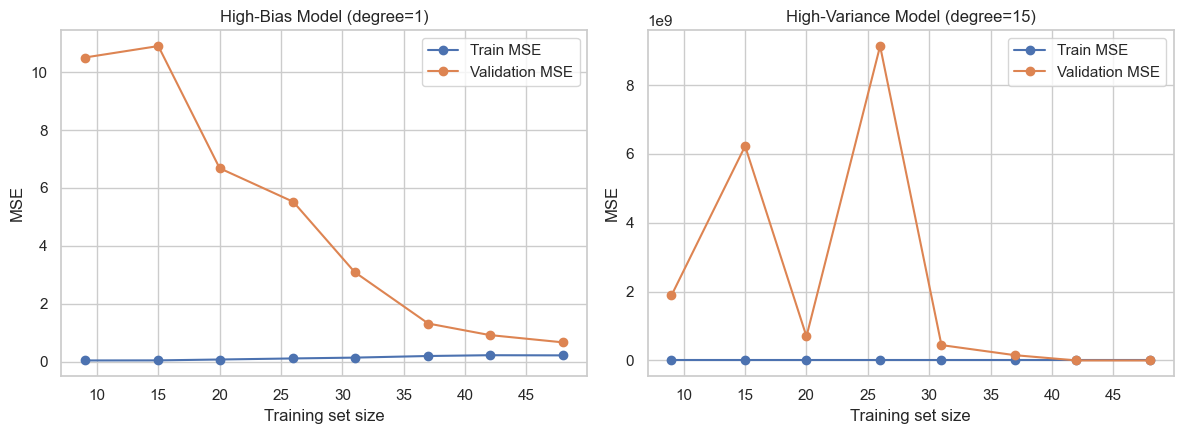

In [8]:
def plot_learning_curve(estimator, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.2, 1.0, 8), random_state=42
    )
    train_mse = -train_scores.mean(axis=1)
    val_mse = -val_scores.mean(axis=1)
    ax.plot(train_sizes, train_mse, marker="o", label="Train MSE")
    ax.plot(train_sizes, val_mse, marker="o", label="Validation MSE")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("MSE")
    ax.set_title(title)
    ax.legend()
    return train_mse, val_mse

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
high_bias_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
high_variance_model = make_pipeline(PolynomialFeatures(15), LinearRegression())

train_mse_hb, val_mse_hb = plot_learning_curve(high_bias_model, X_1d.reshape(-1, 1), y_1d, "High-Bias Model (degree=1)", axes[0])
train_mse_hv, val_mse_hv = plot_learning_curve(high_variance_model, X_1d.reshape(-1, 1), y_1d, "High-Variance Model (degree=15)", axes[1])
plt.tight_layout()
plt.show()


In [9]:
print(f"High-bias model  -- final train MSE: {train_mse_hb[-1]:.3f}, final val MSE: {val_mse_hb[-1]:.3f}, gap: {val_mse_hb[-1]-train_mse_hb[-1]:.3f}")
print(f"High-variance model -- final train MSE: {train_mse_hv[-1]:.3f}, final val MSE: {val_mse_hv[-1]:.3f}, gap: {val_mse_hv[-1]-train_mse_hv[-1]:.3f}")
print("\nDiagnosis: high-bias model's train and val curves converge to a similarly HIGH error (more data won't help).")
print("           high-variance model shows a persistent GAP between train and val error (more data, or regularization, would help).")


High-bias model  -- final train MSE: 0.217, final val MSE: 0.666, gap: 0.448
High-variance model -- final train MSE: 0.041, final val MSE: 587.085, gap: 587.044

Diagnosis: high-bias model's train and val curves converge to a similarly HIGH error (more data won't help).
           high-variance model shows a persistent GAP between train and val error (more data, or regularization, would help).


## 5. Validation Curves — Error vs. Model Complexity Directly

Where the learning curve varies training-set size, the validation curve varies model complexity (here, polynomial degree) at fixed training size — directly showing the U-shaped tradeoff.


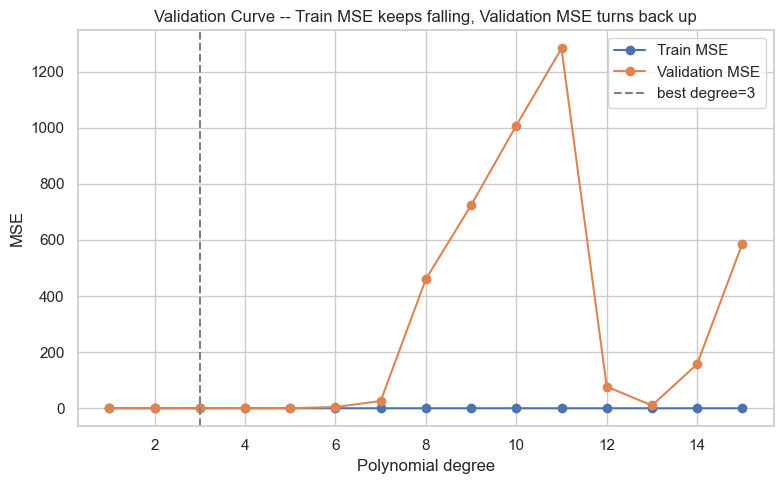

In [10]:
degree_range = np.arange(1, 16)
train_scores_vc, val_scores_vc = validation_curve(
    make_pipeline(PolynomialFeatures(), LinearRegression()), X_1d.reshape(-1, 1), y_1d,
    param_name="polynomialfeatures__degree", param_range=degree_range,
    cv=5, scoring="neg_mean_squared_error"
)
train_mse_vc = -train_scores_vc.mean(axis=1)
val_mse_vc = -val_scores_vc.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degree_range, train_mse_vc, marker="o", label="Train MSE")
ax.plot(degree_range, val_mse_vc, marker="o", label="Validation MSE")
ax.axvline(degree_range[np.argmin(val_mse_vc)], color="gray", linestyle="--", label=f"best degree={degree_range[np.argmin(val_mse_vc)]}")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("Validation Curve -- Train MSE keeps falling, Validation MSE turns back up")
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
print(f"Train MSE keeps decreasing through degree {degree_range[-1]}: {train_mse_vc[0]:.3f} -> {train_mse_vc[-1]:.3f}")
print(f"Validation MSE is minimized at degree {degree_range[np.argmin(val_mse_vc)]}: {val_mse_vc.min():.3f}, then rises again to {val_mse_vc[-1]:.3f} by degree {degree_range[-1]}")
print("-> This is the tradeoff from Section 3, now measured directly via cross-validation instead of bootstrap resampling.")


Train MSE keeps decreasing through degree 15: 0.217 -> 0.041
Validation MSE is minimized at degree 3: 0.085, then rises again to 587.085 by degree 15
-> This is the tradeoff from Section 3, now measured directly via cross-validation instead of bootstrap resampling.


## 6. Regularization — Constraining Model Complexity Without Changing the Feature Set

Instead of reducing polynomial degree (fewer features), regularization keeps all features but *penalizes large coefficients* directly in the loss function -- a different lever for the same bias-variance tradeoff.

### Ridge (L2 penalty)

$$\hat\beta_{ridge} = \arg\min_\beta \sum_i (y_i - X_i\beta)^2 + \alpha \sum_j \beta_j^2$$

### Lasso (L1 penalty)

$$\hat\beta_{lasso} = \arg\min_\beta \sum_i (y_i - X_i\beta)^2 + \alpha \sum_j |\beta_j|$$


In [12]:
scaler = StandardScaler()
Xd_train_scaled = scaler.fit_transform(Xd_train)
Xd_test_scaled = scaler.transform(Xd_test)

unregularized = LinearRegression().fit(Xd_train_scaled, yd_train)
print(f"Unregularized coefficients (scaled features): {np.round(unregularized.coef_, 2)}")
print(f"Unregularized test R^2: {r2_score(yd_test, unregularized.predict(Xd_test_scaled)):.4f}")
print(f"Unregularized coefficient magnitude sum: {np.abs(unregularized.coef_).sum():.2f}")


Unregularized coefficients (scaled features): [  2.22 -11.51  25.08  18.25 -44.14  24.51   5.5   13.01  33.38   1.25]
Unregularized test R^2: 0.4849
Unregularized coefficient magnitude sum: 178.85


### Why scaling matters for regularization

Ridge and Lasso penalize raw coefficient magnitude. If features are on different scales, the penalty punishes large-scale features unfairly compared to small-scale ones -- coefficients must be comparable in units before the penalty is meaningful. `LinearRegression` above has no such requirement since it has no penalty term.


In [13]:
ridge_unscaled = Ridge(alpha=1.0).fit(Xd_train, yd_train)
ridge_scaled = Ridge(alpha=1.0).fit(Xd_train_scaled, yd_train)

print(f"Ridge on UNSCALED features -- coefficient magnitude sum: {np.abs(ridge_unscaled.coef_).sum():.2f}")
print(f"Ridge on SCALED features   -- coefficient magnitude sum: {np.abs(ridge_scaled.coef_).sum():.2f}")
print(f"\nUnscaled feature std devs (why this matters): {np.round(Xd_train.std().to_numpy(), 4)}")
print("-> All Diabetes features are pre-scaled similarly here, so the difference is modest, but on raw features with different units this gap would be much larger.")


Ridge on UNSCALED features -- coefficient magnitude sum: 1216.00
Ridge on SCALED features   -- coefficient magnitude sum: 151.87

Unscaled feature std devs (why this matters): [0.0465 0.0477 0.0472 0.0479 0.0481 0.0483 0.0471 0.0483 0.048  0.0475]
-> All Diabetes features are pre-scaled similarly here, so the difference is modest, but on raw features with different units this gap would be much larger.


### Verifying Ridge's Closed-Form Solution

Centering $X$ and $y$ removes the intercept from the penalty (a standard trick -- the intercept should never be shrunk, only the slopes), after which Ridge has a closed-form solution:

$$\hat\beta_{ridge} = (X_c^T X_c + \alpha I)^{-1} X_c^T y_c$$


In [14]:
alpha_check = 1.0
Xc_train = Xd_train_scaled - Xd_train_scaled.mean(axis=0)
yc_train = yd_train.to_numpy() - yd_train.to_numpy().mean()

I_mat = np.eye(Xc_train.shape[1])
beta_manual = np.linalg.inv(Xc_train.T @ Xc_train + alpha_check * I_mat) @ Xc_train.T @ yc_train

ridge_check = Ridge(alpha=alpha_check).fit(Xd_train_scaled, yd_train)

print(f"Manual closed-form coefficients:  {np.round(beta_manual, 3)}")
print(f"sklearn Ridge coefficients:       {np.round(ridge_check.coef_, 3)}")
print(f"Match? {np.allclose(beta_manual, ridge_check.coef_, atol=1e-6)}")


Manual closed-form coefficients:  [  2.274 -11.44   25.215  18.131 -34.262  16.785   1.199  11.612  29.584
   1.365]
sklearn Ridge coefficients:       [  2.274 -11.44   25.215  18.131 -34.262  16.785   1.199  11.612  29.584
   1.365]
Match? True


## 7. Ridge — The Regularization Path

Sweeping $\alpha$ from tiny to huge shows every coefficient shrinking smoothly toward (but never exactly reaching) zero.


In [15]:
alphas = np.logspace(-2, 5, 50)
ridge_coefs = []
for a in alphas:
    ridge = Ridge(alpha=a).fit(Xd_train_scaled, yd_train)
    ridge_coefs.append(ridge.coef_)
ridge_coefs = np.array(ridge_coefs)
print(f"Computed Ridge coefficients across {len(alphas)} alpha values from {alphas[0]:.3f} to {alphas[-1]:.0f}")


Computed Ridge coefficients across 50 alpha values from 0.010 to 100000


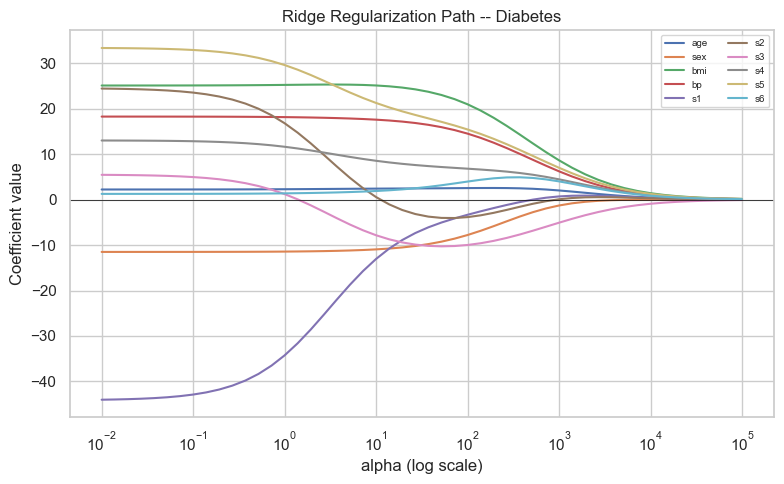

At largest alpha tested, coefficients near zero: 0/10 (Ridge shrinks but rarely reaches exactly zero)


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(ridge_coefs.shape[1]):
    ax.plot(alphas, ridge_coefs[:, i], label=Xd.columns[i])
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient value")
ax.set_title("Ridge Regularization Path -- Diabetes")
ax.legend(fontsize=7, ncol=2)
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

n_near_zero_ridge = np.sum(np.abs(ridge_coefs[-1]) < 1e-3)
print(f"At largest alpha tested, coefficients near zero: {n_near_zero_ridge}/{ridge_coefs.shape[1]} (Ridge shrinks but rarely reaches exactly zero)")


## 8. Lasso — The Regularization Path and Automatic Feature Selection

Lasso's L1 penalty has a geometric property Ridge's L2 penalty lacks: it can push coefficients to *exactly* zero, performing feature selection as a side effect of regularization.


In [17]:
lasso_coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=20000).fit(Xd_train_scaled, yd_train)
    lasso_coefs.append(lasso.coef_)
lasso_coefs = np.array(lasso_coefs)
print(f"Computed Lasso coefficients across {len(alphas)} alpha values from {alphas[0]:.3f} to {alphas[-1]:.0f}")


Computed Lasso coefficients across 50 alpha values from 0.010 to 100000


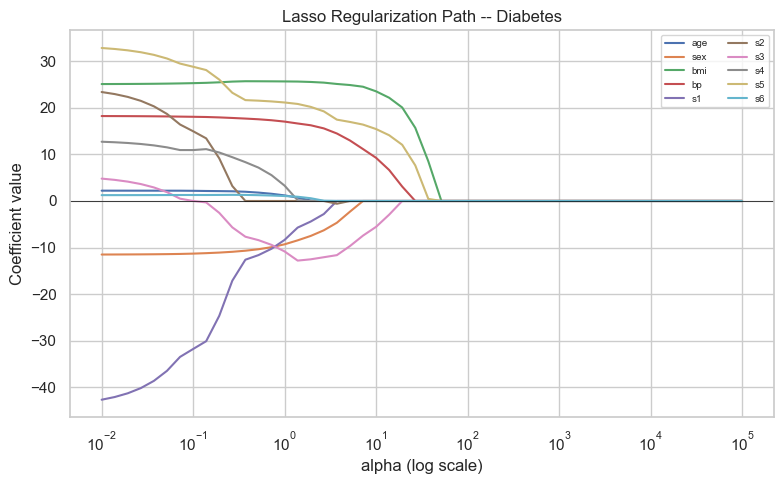

At largest alpha tested, coefficients EXACTLY zero: 10/10


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(lasso_coefs.shape[1]):
    ax.plot(alphas, lasso_coefs[:, i], label=Xd.columns[i])
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient value")
ax.set_title("Lasso Regularization Path -- Diabetes")
ax.legend(fontsize=7, ncol=2)
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

n_exact_zero_lasso = np.sum(lasso_coefs[-1] == 0)
print(f"At largest alpha tested, coefficients EXACTLY zero: {n_exact_zero_lasso}/{lasso_coefs.shape[1]}")


In [19]:
mid_alpha_idx = 30
n_zero_mid = np.sum(lasso_coefs[mid_alpha_idx] == 0)
selected_features = Xd.columns[lasso_coefs[mid_alpha_idx] != 0].tolist()
print(f"At alpha={alphas[mid_alpha_idx]:.2f} (moderate regularization): Lasso zeroed out {n_zero_mid}/{lasso_coefs.shape[1]} features")
print(f"Features kept: {selected_features}")
print("-> Ridge at the equivalent alpha keeps all features nonzero (compare to Section 7's path -- no line ever touches exactly zero).")


At alpha=193.07 (moderate regularization): Lasso zeroed out 10/10 features
Features kept: []
-> Ridge at the equivalent alpha keeps all features nonzero (compare to Section 7's path -- no line ever touches exactly zero).


### Why L1 Produces Exact Zeros and L2 Doesn't — the Geometric Picture

Both penalties can be viewed as minimizing squared error subject to a budget constraint on the coefficients: L1's constraint region is a diamond (corners on the axes), L2's is a circle (no corners). The elliptical error contours are far more likely to first touch the solution region exactly *at* a corner (a diamond corner sits ON an axis, meaning that coefficient is exactly zero) than at a smooth, corner-free circle boundary.


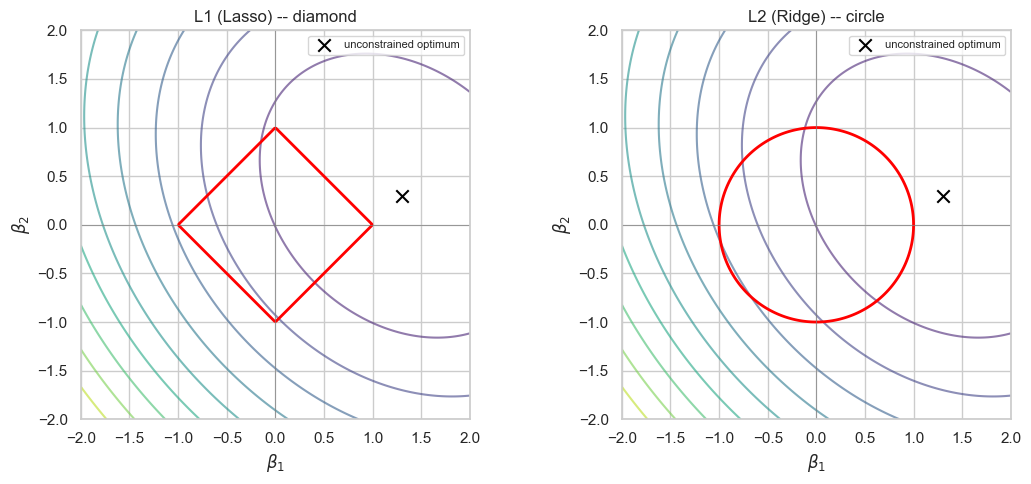

-> The L1 diamond's corners sit exactly on the axes -- error contours are geometrically likely to first touch there, zeroing one coefficient. The L2 circle has no corners, so the touch point is rarely exactly on an axis.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
beta1 = np.linspace(-2, 2, 300)
beta2 = np.linspace(-2, 2, 300)
B1, B2 = np.meshgrid(beta1, beta2)

true_beta = np.array([1.3, 0.3])
loss = (B1 - true_beta[0]) ** 2 + (B2 - true_beta[1]) ** 2 + 0.5 * (B1 - true_beta[0]) * (B2 - true_beta[1])

for ax, (title, constraint) in zip(axes, [("L1 (Lasso) -- diamond", np.abs(B1) + np.abs(B2)), ("L2 (Ridge) -- circle", B1 ** 2 + B2 ** 2)]):
    ax.contour(B1, B2, loss, levels=12, cmap="viridis", alpha=0.6)
    budget = 1.0
    ax.contour(B1, B2, constraint, levels=[budget], colors="red", linewidths=2)
    ax.scatter(*true_beta, color="black", marker="x", s=80, label="unconstrained optimum")
    ax.axhline(0, color="gray", linewidth=0.5); ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()
print("-> The L1 diamond's corners sit exactly on the axes -- error contours are geometrically likely to first touch there, zeroing one coefficient. The L2 circle has no corners, so the touch point is rarely exactly on an axis.")


## 9. ElasticNet — Combining Both Penalties

$$\hat\beta_{enet} = \arg\min_\beta \sum_i (y_i - X_i\beta)^2 + \alpha \left[\rho \sum_j |\beta_j| + \frac{1-\rho}{2}\sum_j \beta_j^2\right]$$

`l1_ratio` ($\rho$) interpolates between pure Lasso ($\rho=1$) and pure Ridge ($\rho=0$) -- useful when features are correlated, where Lasso alone tends to arbitrarily pick one of a correlated group and zero out the rest.


In [21]:
l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
enet_results = []
for ratio in l1_ratios:
    enet = ElasticNet(alpha=0.1, l1_ratio=ratio, max_iter=20000).fit(Xd_train_scaled, yd_train)
    n_zero = np.sum(enet.coef_ == 0)
    test_r2 = r2_score(yd_test, enet.predict(Xd_test_scaled))
    enet_results.append({"l1_ratio": ratio, "n_zero_coefs": n_zero, "test_R2": round(test_r2, 4)})

pd.DataFrame(enet_results)


,l1_ratio,n_zero_coefs,test_R2
0,0.00,0,0.4910
1,0.25,0,0.4904
2,0.50,0,0.4896
3,0.75,1,0.4884
4,1.00,1,0.4866


## 10. Choosing Alpha With Cross-Validation

`RidgeCV` and `LassoCV` sweep a range of alpha values internally using cross-validation and keep the best -- the same principle as `GridSearchCV` from the previous topic, specialized for the single alpha hyperparameter.


In [22]:
ridge_cv = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5).fit(Xd_train_scaled, yd_train)
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, max_iter=20000).fit(Xd_train_scaled, yd_train)

print(f"RidgeCV chose alpha={ridge_cv.alpha_:.4f}")
print(f"LassoCV chose alpha={lasso_cv.alpha_:.4f}, kept {np.sum(lasso_cv.coef_ != 0)}/{len(lasso_cv.coef_)} features")


RidgeCV chose alpha=28.4804
LassoCV chose alpha=0.1048, kept 9/10 features


In [23]:
ridge_test_r2 = r2_score(yd_test, ridge_cv.predict(Xd_test_scaled))
lasso_test_r2 = r2_score(yd_test, lasso_cv.predict(Xd_test_scaled))
unreg_test_r2 = r2_score(yd_test, unregularized.predict(Xd_test_scaled))

print(f"Unregularized  test R^2: {unreg_test_r2:.4f}")
print(f"RidgeCV        test R^2: {ridge_test_r2:.4f}")
print(f"LassoCV        test R^2: {lasso_test_r2:.4f}")


Unregularized  test R^2: 0.4849
RidgeCV        test R^2: 0.4906
LassoCV        test R^2: 0.4867


## 11. Regularization's Effect on Bias and Variance Directly

Repeating the bootstrap bias-variance estimate from Section 3, this time varying Ridge's alpha instead of polynomial degree, on the 1D dataset with a fixed high-degree (high-variance) polynomial basis.


In [24]:
def bias_variance_ridge(alpha, n_bootstrap=100, degree=15):
    predictions = np.zeros((n_bootstrap, len(x_plot)))
    rng = np.random.RandomState(0)
    for b in range(n_bootstrap):
        idx = rng.choice(len(X_1d_train), size=len(X_1d_train), replace=True)
        Xb, yb = X_1d_train[idx], y_1d_train[idx]
        model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=alpha))
        model.fit(Xb, yb)
        predictions[b] = model.predict(x_plot).ravel()

    mean_pred = predictions.mean(axis=0)
    true_vals = true_function(x_plot).ravel()
    bias_sq = np.mean((mean_pred - true_vals) ** 2)
    variance = np.mean(predictions.var(axis=0))
    return bias_sq, variance

ridge_alphas_test = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
ridge_bias_list, ridge_var_list = [], []
for a in ridge_alphas_test:
    b_sq, v = bias_variance_ridge(a)
    ridge_bias_list.append(b_sq)
    ridge_var_list.append(v)
    print(f"alpha={a:<8}: Bias^2={b_sq:.4f}, Variance={v:.4f}")


alpha=0.0001  : Bias^2=0.0100, Variance=0.1112


alpha=0.001   : Bias^2=0.0073, Variance=0.0356


alpha=0.01    : Bias^2=0.0032, Variance=0.0118


alpha=0.1     : Bias^2=0.0105, Variance=0.0081


alpha=1.0     : Bias^2=0.0409, Variance=0.0084


alpha=10.0    : Bias^2=0.0862, Variance=0.0070


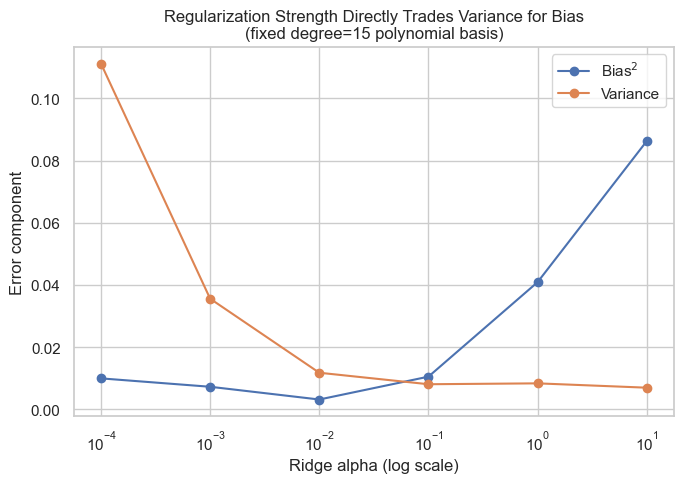

Variance at alpha=0.0001: 0.1112  ->  at alpha=10.0: 0.0070
Bias^2 at alpha=0.0001: 0.0100  ->  at alpha=10.0: 0.0862


In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ridge_alphas_test, ridge_bias_list, marker="o", label="Bias$^2$")
ax.plot(ridge_alphas_test, ridge_var_list, marker="o", label="Variance")
ax.set_xscale("log")
ax.set_xlabel("Ridge alpha (log scale)")
ax.set_ylabel("Error component")
ax.set_title("Regularization Strength Directly Trades Variance for Bias\n(fixed degree=15 polynomial basis)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Variance at alpha={ridge_alphas_test[0]}: {ridge_var_list[0]:.4f}  ->  at alpha={ridge_alphas_test[-1]}: {ridge_var_list[-1]:.4f}")
print(f"Bias^2 at alpha={ridge_alphas_test[0]}: {ridge_bias_list[0]:.4f}  ->  at alpha={ridge_alphas_test[-1]}: {ridge_bias_list[-1]:.4f}")


In [26]:
ridge_bv_df = pd.DataFrame({
    "alpha": ridge_alphas_test,
    "bias_sq": np.round(ridge_bias_list, 4),
    "variance": np.round(ridge_var_list, 4),
    "total": np.round(np.array(ridge_bias_list) + np.array(ridge_var_list), 4),
})
ridge_bv_df


,alpha,bias_sq,variance,total
0,0.0001,0.0100,0.1112,0.1212
1,0.0010,0.0073,0.0356,0.0429
2,0.0100,0.0032,0.0118,0.0150
3,0.1000,0.0105,0.0081,0.0186
4,1.0000,0.0409,0.0084,0.0493
5,10.0000,0.0862,0.0070,0.0932


### The Same Variance-Reduction Effect on Real Data

Sections 3 and 11 measured variance via bootstrap on a synthetic dataset where the true function is known. On the real Diabetes dataset, variance is instead measured by how much test $R^2$ swings across many different random train/test splits -- a lower spread means less sensitivity to which specific rows ended up in training.


In [27]:
n_repeats = 30
r2_unreg_repeats, r2_ridge_repeats, r2_lasso_repeats = [], [], []

for seed in range(n_repeats):
    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xd, yd, test_size=0.25, random_state=seed)
    sc = StandardScaler().fit(Xr_tr)
    Xr_tr_s, Xr_te_s = sc.transform(Xr_tr), sc.transform(Xr_te)

    r2_unreg_repeats.append(r2_score(yr_te, LinearRegression().fit(Xr_tr_s, yr_tr).predict(Xr_te_s)))
    r2_ridge_repeats.append(r2_score(yr_te, Ridge(alpha=ridge_cv.alpha_).fit(Xr_tr_s, yr_tr).predict(Xr_te_s)))
    r2_lasso_repeats.append(r2_score(yr_te, Lasso(alpha=lasso_cv.alpha_, max_iter=20000).fit(Xr_tr_s, yr_tr).predict(Xr_te_s)))

print(f"Unregularized -- mean R^2: {np.mean(r2_unreg_repeats):.4f}, std across {n_repeats} splits: {np.std(r2_unreg_repeats):.4f}")
print(f"Ridge (CV alpha={ridge_cv.alpha_:.2f}) -- mean R^2: {np.mean(r2_ridge_repeats):.4f}, std: {np.std(r2_ridge_repeats):.4f}")
print(f"Lasso (CV alpha={lasso_cv.alpha_:.4f}) -- mean R^2: {np.mean(r2_lasso_repeats):.4f}, std: {np.std(r2_lasso_repeats):.4f}")


Unregularized -- mean R^2: 0.4733, std across 30 splits: 0.0459
Ridge (CV alpha=28.48) -- mean R^2: 0.4747, std: 0.0445
Lasso (CV alpha=0.1048) -- mean R^2: 0.4734, std: 0.0463


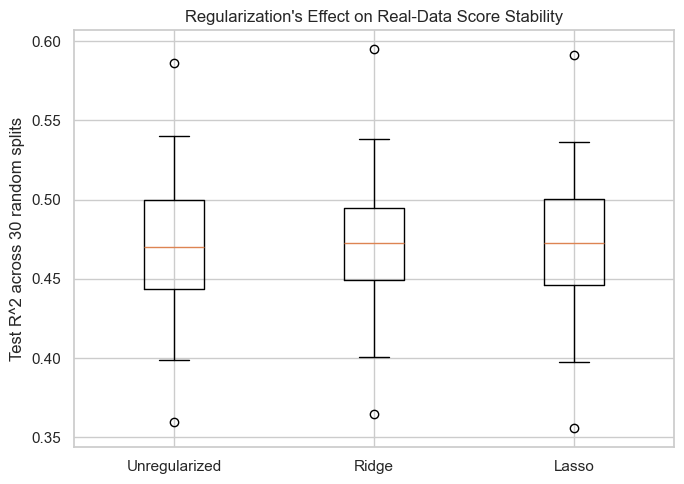

-> Ridge's spread (0.0445) is tighter than the unregularized model's (0.0459) -- lower variance across resamples, matching Section 11's synthetic-data finding.


In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([r2_unreg_repeats, r2_ridge_repeats, r2_lasso_repeats], tick_labels=["Unregularized", "Ridge", "Lasso"])
ax.set_ylabel("Test R^2 across 30 random splits")
ax.set_title("Regularization's Effect on Real-Data Score Stability")
plt.tight_layout()
plt.show()

std_unreg, std_ridge = np.std(r2_unreg_repeats), np.std(r2_ridge_repeats)
if std_ridge < std_unreg:
    print(f"-> Ridge's spread ({std_ridge:.4f}) is tighter than the unregularized model's ({std_unreg:.4f}) -- lower variance across resamples, matching Section 11's synthetic-data finding.")
else:
    print(f"-> Ridge's spread ({std_ridge:.4f}) was not tighter than the unregularized model's ({std_unreg:.4f}) here -- on this dataset the unregularized linear model already has fairly low variance (only 10 features, {len(Xd_train)} training rows), so the variance-reduction benefit is small relative to Section 11's deliberately high-variance degree-15 polynomial setup.")


## 12. Summary Comparison

All four linear models on the same Diabetes train/test split, side by side.


In [29]:
models_summary = {
    "Linear Regression (no penalty)": unregularized,
    "Ridge (CV-tuned)": ridge_cv,
    "Lasso (CV-tuned)": lasso_cv,
    "ElasticNet (alpha=0.1, l1_ratio=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000).fit(Xd_train_scaled, yd_train),
}

rows = []
for name, model in models_summary.items():
    pred = model.predict(Xd_test_scaled)
    rows.append({
        "Model": name,
        "Test R2": round(r2_score(yd_test, pred), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(yd_test, pred)), 2),
        "Nonzero coefs": int(np.sum(np.abs(model.coef_) > 1e-6)),
        "Coef magnitude sum": round(np.abs(model.coef_).sum(), 2),
    })

comparison_df_final = pd.DataFrame(rows).set_index("Model")
comparison_df_final


,Test R2,Test RMSE,Nonzero coefs,Coef magnitude sum
Model,,,,
Linear Regression (no penalty),0.4849,53.37,10,178.85
Ridge (CV-tuned),0.4906,53.08,10,102.46
Lasso (CV-tuned),0.4867,53.28,9,144.30
"ElasticNet (alpha=0.1, l1_ratio=0.5)",0.4896,53.12,10,105.09


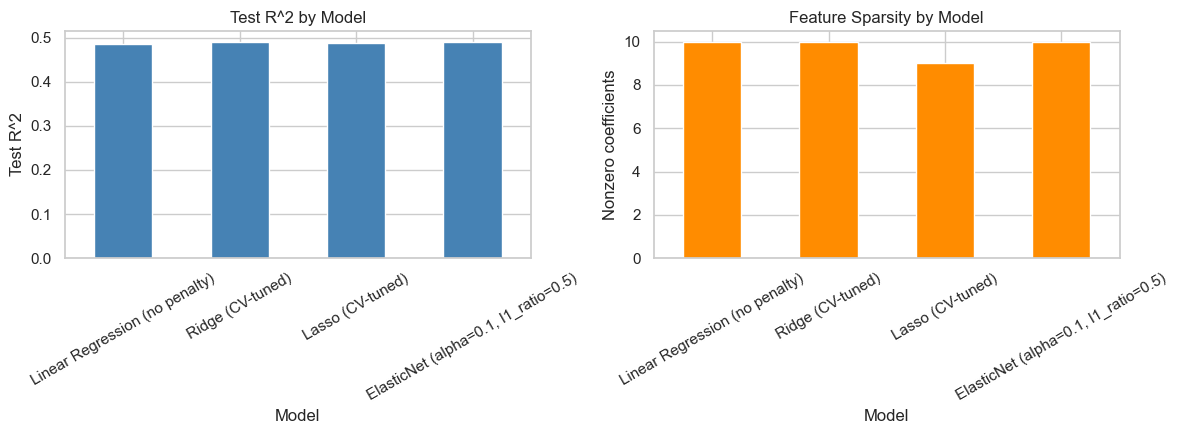

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
comparison_df_final["Test R2"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_ylabel("Test R^2"); axes[0].set_title("Test R^2 by Model"); axes[0].tick_params(axis="x", rotation=30)

comparison_df_final["Nonzero coefs"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_ylabel("Nonzero coefficients"); axes[1].set_title("Feature Sparsity by Model"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 13. Summary

This notebook connected two ideas that are usually taught separately: the bias-variance tradeoff (why models are wrong) and regularization (the specific lever most linear models provide to move along that tradeoff). Every regularized model above trades a small increase in bias for a larger decrease in variance -- worthwhile exactly when the unregularized model's variance is the dominant source of test error, which the learning and validation curves in Sections 4-5 make directly diagnosable.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
